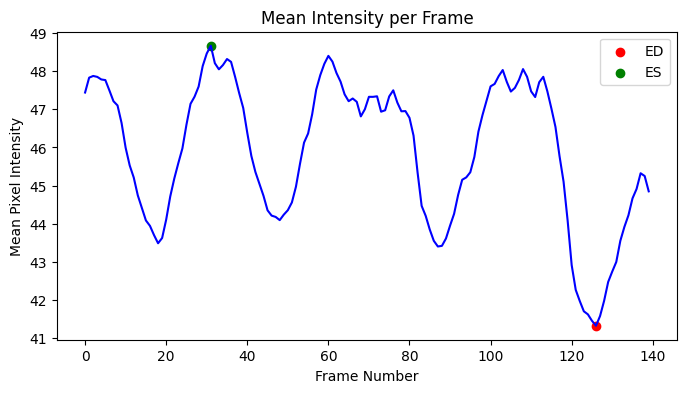

ED frame index: 126, ES frame index: 31


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_ed_es_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    intensities = []
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray)
        intensities.append(mean_intensity)
        frames.append(frame)

    cap.release()
    intensities = np.array(intensities)


    ed_frame_idx = np.argmin(intensities)  
    es_frame_idx = np.argmax(intensities) 

 
    plt.figure(figsize=(8, 4))
    plt.plot(intensities, color='blue')
    plt.scatter(ed_frame_idx, intensities[ed_frame_idx], color='red', label='ED')
    plt.scatter(es_frame_idx, intensities[es_frame_idx], color='green', label='ES')
    plt.title("Mean Intensity per Frame")
    plt.xlabel("Frame Number")
    plt.ylabel("Mean Pixel Intensity")
    plt.legend()
    plt.show()

    return frames[ed_frame_idx], frames[es_frame_idx], ed_frame_idx, es_frame_idx


video_path = "EchoNet-Dynamic/Videos/0X1A0A263B22CCD966.avi"  
ed_frame, es_frame, ed_idx, es_idx = find_ed_es_frames(video_path)

print(f"ED frame index: {ed_idx}, ES frame index: {es_idx}")


cv2.imshow("End-Diastole (ED)", ed_frame)
cv2.imshow("End-Systole (ES)", es_frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np


videos_folder = "EchoNet-Dynamic/Videos/"       
labels_csv = "EchoNet-Dynamic/FileList.csv"      
output_folder = "dataset/"      


os.makedirs(f"{output_folder}/ED", exist_ok=True)
os.makedirs(f"{output_folder}/ES", exist_ok=True)


df = pd.read_csv(labels_csv)

ed_records = []
es_records = []

def extract_ed_es_frames(video_path):
    """Detect approximate ED and ES frames from motion energy."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️ Could not open {video_path}")
        return None, None, None

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
    cap.release()

    frames = np.array(frames)
    diffs = np.array([np.sum(cv2.absdiff(frames[i], frames[i - 1])) for i in range(1, len(frames))])


    es_idx = int(np.argmax(diffs))
    ed_idx = int(np.argmin(diffs))

    return ed_idx, es_idx, frames


for _, row in df.iterrows():
    vid_id = row["FileName"]
    edv = row["EDV"]
    esv = row["ESV"]
    video_path = os.path.join(videos_folder, f"{vid_id}.avi")

    if not os.path.exists(video_path):
        print(f"⚠️ Missing video: {video_path}")
        continue

    ed_idx, es_idx, frames = extract_ed_es_frames(video_path)
    if frames is None:
        continue


    ed_path = f"{output_folder}/ED/{vid_id}.png"
    cv2.imwrite(ed_path, frames[ed_idx])
    ed_records.append({"FileName": vid_id, "EDV": edv})


    es_path = f"{output_folder}/ES/{vid_id}.png"
    cv2.imwrite(es_path, frames[es_idx])
    es_records.append({"FileName": vid_id, "ESV": esv})

    print(f"✅ {vid_id} -> ED:{ed_idx}, ES:{es_idx}")


pd.DataFrame(ed_records).to_csv(f"{output_folder}/ed_labels.csv", index=False)
pd.DataFrame(es_records).to_csv(f"{output_folder}/es_labels.csv", index=False)

print("\n🎉 Dataset built successfully!")
print(f"ED frames saved in {output_folder}/ED/")
print(f"ES frames saved in {output_folder}/ES/")

✅ 0X100009310A3BD7FC -> ED:164, ES:134
✅ 0X1002E8FBACD08477 -> ED:201, ES:4
✅ 0X1005D03EED19C65B -> ED:83, ES:102
✅ 0X10075961BC11C88E -> ED:106, ES:83
✅ 0X10094BA0A028EAC3 -> ED:196, ES:0
✅ 0X100CF05D141FF143 -> ED:180, ES:94
✅ 0X100E3B8D3280BEC5 -> ED:62, ES:47
✅ 0X100E491B3CD58DE2 -> ED:43, ES:88
✅ 0X100F044876B98F90 -> ED:156, ES:172
✅ 0X101026B90DAE7E95 -> ED:84, ES:116
✅ 0X1012703CDC1436FE -> ED:140, ES:25
✅ 0X1013E8A4864781B -> ED:44, ES:3
✅ 0X1018521A3BC5CDBA -> ED:155, ES:24
✅ 0X101C388397F66EDB -> ED:82, ES:46
✅ 0X101CFC9C5351DCBE -> ED:59, ES:48
✅ 0X101E654AF3FC07A8 -> ED:15, ES:97
✅ 0X10267ADF2E644E0 -> ED:39, ES:126
✅ 0X102AE9C68B2C46DA -> ED:63, ES:157
✅ 0X102C51641C321436 -> ED:14, ES:86
✅ 0X102CFB07F752AAE6 -> ED:154, ES:189
✅ 0X102DD1B9BE03716 -> ED:199, ES:32
✅ 0X102E453603FA1440 -> ED:180, ES:1
✅ 0X102E94908346DE1D -> ED:130, ES:35
✅ 0X102F3D4CD5E10801 -> ED:118, ES:142
✅ 0X10365E52F01510B4 -> ED:49, ES:82
✅ 0X1039108E17193B1C -> ED:105, ES:226
✅ 0X1039B49145DF4F25 -